# **Практическая работа №2. Использование глубоких нейронных сетей для решения задач регрессии и классификации**



## **Задание №1. Обучение модели ИНС для решения задачи регрессии**



Постройте глубокую нейронную сеть для предсказания цен на недвижимость в городе Бостон, используя датасет датасет boston_housing_price

[Описание датасета](https://www.hackersrealm.net/post/boston-house-price-prediction-analysis-using-python)

#### 1.1. Загружаем исходные данные:

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("./sample_data/Boston Dataset.csv")

# Удаляем лишний индекс
df = df.drop(columns=["Unnamed: 0"])

# Выделяем признаки и целевую переменную
x = df.drop(columns=["medv"]).values
y = df["medv"].values

print(x.shape, y.shape)

(506, 13) (506,)


In [ ]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


#### 1.2. Проектируем архитектуру для этой задачи

In [ ]:
# Ваш код
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

model = Sequential([
    Dense(16, input_shape=(13,), activation='relu'),
    Dense(1, activation='relu')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 1.3. Компилируем модель ИНС

Подберите нужную функцию потерь и метрику.

In [ ]:
# Ваш код
model.compile(optimizer='sgd', loss='mse', metrics=['mae'])

#### 1.4. Обучаем модель ИНС

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((404, 13), (102, 13))

In [ ]:
model.fit(X_train, y_train, epochs=25)

Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 946032448922189824.0000 - mae: 411160192.0000
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1283585470365696.0000 - mae: 35762256.0000 
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 759106545647616.0000 - mae: 27501976.0000 
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 448932127703040.0000 - mae: 21149634.0000 
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 265496523964416.0000 - mae: 16264547.0000 
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 157013434695680.0000 - mae: 12507800.0000 
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 92857008390144.0000 - mae: 9618778.0000   
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 54915212771328.0000 - mae: 7397055.0000 
Epoch 9/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32476604923904.0000 - mae: 5688500.5000 
Epoch 10/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19206521225216.0000 - mae: 43745

In [ ]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()

X_train_n = mms.fit_transform(X_train)
X_test_n = mms.transform(X_test)

In [ ]:
model = Sequential([
    Dense(16, input_shape=(13,), activation='relu'),
    Dense(1)
])

model.compile(optimizer='sgd', loss='mse', metrics=['mae'])

model.fit(X_train_n, y_train, epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 293.7350 - mae: 14.1980  
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 64.0048 - mae: 5.9055 
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 56.6611 - mae: 5.4584 
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 49.6627 - mae: 5.1693 
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 33.9557 - mae: 4.2375 
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 50.0287 - mae: 5.2590 
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 41.4547 - mae: 4.9089 
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 55.7440 - mae: 6.0184 
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 45.5964 - mae: 4.8884 
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.9481 - mae: 4.0067 


#### 1.6. Делаем предсказания на тестовых данных

In [ ]:
# Ваш код
preds = model.predict(X_test_n)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


#### 1.7. Вычисляем метрику качества на тестовых данных

In [ ]:
# Ваш код
from sklearn.metrics import mean_absolute_error

mean_absolute_error(preds, y_test)

3.0074288503796445

#### 1.8. Строим график обучения

In [ ]:
H = model.fit(
    X_train_n, y_train,
    validation_data=(X_test_n, y_test),
    epochs=25,
    batch_size=32
)

Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 27.4902 - mae: 3.6110 - val_loss: 63.1469 - val_mae: 6.5499
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 61.9943 - mae: 6.0503 - val_loss: 28.5123 - val_mae: 3.3400
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 31.2986 - mae: 4.1153 - val_loss: 34.7078 - val_mae: 4.1515
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 24.8529 - mae: 3.7120 - val_loss: 21.9302 - val_mae: 2.9663
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 31.1103 - mae: 3.9154 - val_loss: 29.0294 - val_mae: 4.2151
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 26.7616 - mae: 3.8589 - val_loss: 21.8010 - val_mae: 3.0417
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25.1882 - mae: 3.5861 - val_loss: 22.2844 - val_mae: 2.8222
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 21.4023 - mae: 3.2067 - val_loss: 21.4120 - val_mae: 3.0256
Epoch 9/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - los

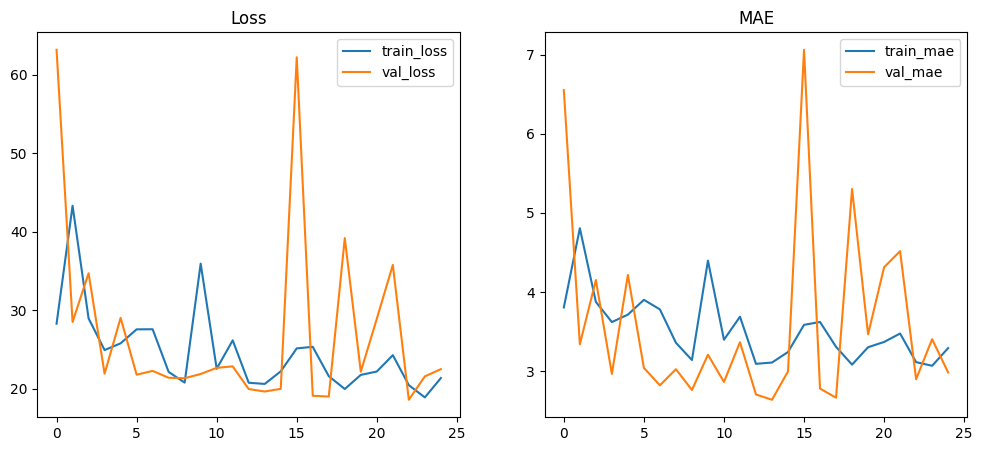

In [ ]:
import matplotlib.pyplot as plt
epochs = np.arange(len(H.history['loss']))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, H.history['loss'], label='train_loss')
plt.plot(epochs, H.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(epochs, H.history['mae'], label='train_mae')
plt.plot(epochs, H.history['val_mae'], label='val_mae')
plt.legend()
plt.title("MAE")

plt.show()

In [ ]:
import joblib
model.save("./sample_data/boston.keras")
joblib.dump(mms, "./sample_data/boston_scaler.pkl")

print("✅ Модель сохранена:  boston.h5")
print("✅ Scaler сохранен:  boston_scaler.pkl")


✅ Модель сохранена:  boston.h5
✅ Scaler сохранен:  boston_scaler.pkl


#### 1.9. Построение графического интерфейса в Gradio Проверка обученной модели пользовательскими данными

In [ ]:
# Ваш код
import gradio as gr
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# Загружаем модель и scaler
model = load_model("./sample_data/boston.keras")
scaler = joblib.load("./sample_data/boston_scaler.pkl")  # это твой mms (MinMaxScaler) или sc (StandardScaler)

# Функция предсказания
def predict_medv(crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, black, lstat):
    x = np.array([[crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, black, lstat]], dtype=np.float32)
    x_n = scaler.transform(x)
    pred = model.predict(x_n, verbose=0).squeeze()
    return float(pred)

# Поля ввода
inputs = [
    gr.Number(label="crim"),
    gr.Number(label="zn"),
    gr.Number(label="indus"),
    gr.Number(label="chas"),
    gr.Number(label="nox"),
    gr.Number(label="rm"),
    gr.Number(label="age"),
    gr.Number(label="dis"),
    gr.Number(label="rad"),
    gr.Number(label="tax)"),
    gr.Number(label="ptratio"),
    gr.Number(label="black"),
    gr.Number(label="lstat"),
]

demo = gr.Interface(
    fn=predict_medv,
    inputs=inputs,
    outputs=gr.Number(label="Predicted MEDV"),
)

demo.launch(debug=True)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1526d4c0fb0b51e9b8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://1526d4c0fb0b51e9b8.gradio.live


#### 2. Проверка обученной модели пользовательскими данными

In [ ]:
# Ваш код
user_data = [
    0.02,   # crim
    0.0,    # zn
    7.0,    # indus
    0,      # chas
    0.5,    # nox
    6.5,    # rm
    65,     # age
    4.0,    # dis
    4,      # rad
    300,    # tax
    15.0,   # ptratio
    390.0,  # black
    5.0     # lstat
]

user_data = np.array([user_data])
user_data_n = mms.transform(user_data)
prediction = model.predict(user_data_n)

print(f"Прогноз MEDV: {prediction[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Прогноз MEDV: 28.88


## **Задание №2.Обучение модели ИНС для решения задачи классификации**



Порядок работы:

* 1. Собрать датасет из изображений, соответствующих не менее, чем 3 классам объектов (в
примере с пары были кошки, собаки и панды).


- 2. Для каждого класса должно быть собрано не менее 1000 изображений. Количество
изображений для каждого класса должно быть одинаковым.
Готовые датасеты можно скачать отсюда: https://www.kaggle.com/


- 3. Обучить модель глубокой нейронной сети для решения задачи классификации
изображений, по выбранным Вами классам. (В качестве примера приведён код с пары)
В конечном итоге Вы должны сохранить обученную модель для классификации
изображений, соответствующих тем классам, которые Вы выбрали, а затем воспользоваться этой моделью для предсказания классов на пользовательских изображениях.



> При выполнении заданий пробуйте использовать разные функции потерь,
методы оптимизации, функции активации и метрики ошибок.

### 1. Устанавливаем зависимости:

In [ ]:
# Импортируем LabelBinarizer для преобразования текстовых меток в векторы
# (например, "кошка" -> [1, 0, 0], "собака" -> [0, 1, 0], "панда" -> [0, 0, 1])
from sklearn.preprocessing import LabelBinarizer

# Импортируем train_test_split для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Импортируем classification_report для оценки качества классификации
from sklearn.metrics import classification_report

# Импортируем Sequential для создания последовательной модели нейронной сети
from keras.models import Sequential

# Импортируем Dense для создания плотных слоев нейронной сети
from keras.layers import Dense

# Импортируем SGD и Adam для оптимизации обучения нейронной сети
from keras.optimizers import SGD, Adam

# Импортируем paths из imutils для удобной работы с путями к изображениям
from imutils import paths

# Импортируем pyplot из matplotlib для визуализации данных
import matplotlib.pyplot as plt

# Импортируем numpy для работы с массивами данных
import numpy as np

# Импортируем random для генерации случайных чисел
import random

# Импортируем pickle для сериализации и десериализации данных
import pickle

# Импортируем cv2 для работы с изображениями
import cv2

# Импортируем os для работы с файловой системой
import os

# Импортируем cv2_imshow из google.colab.patches для отображения изображений в Colab
from google.colab.patches import cv2_imshow

### 2. Загружаем набор данных:

In [ ]:
# Ваш код
# Скачиваем архив с набором данных
!curl -L -o indian_birds.zip \
  https://www.kaggle.com/api/v1/datasets/download/arjunbasandrai/25-indian-bird-species-with-226k-images

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 9557M  100 9557M    0     0  76.1M      0  0:02:05  0:02:05 --:--:--  132M


In [ ]:
%%capture
# Распаковываем архив в папку dataset (%%capture подавляет вывод большого списка файлов)
!unzip indian_birds.zip -d dataset

In [ ]:
!mv /content/dataset/training_set/training_set/* /content/dataset/training_set/

In [ ]:
import os
import shutil

base_path = "/content/dataset/training_set/training_set"

# Папки, которые нужно оставить
keep_folders = [
    "Asian Green Bee-Eater",
    "Brown-Headed Barbet",
    "Common Kingfisher"
]

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    if os.path.isdir(folder_path) and folder not in keep_folders:
        shutil.rmtree(folder_path)
        print(f"Удалена папка: {folder}")

print("Готово ✅")

Удалена папка: White-Breasted Waterhen
Удалена папка: White Wagtail
Удалена папка: Common Rosefinch
Удалена папка: White-Breasted Kingfisher
Удалена папка: Rufous Treepie
Удалена папка: House Crow
Удалена папка: Ruddy Shelduck
Удалена папка: Sarus Crane
Удалена папка: Indian Pitta
Удалена папка: Common Tailorbird
Удалена папка: Indian Grey Hornbill
Удалена папка: Northern Lapwing
Удалена папка: Jungle Babbler
Удалена папка: Gray Wagtail
Удалена папка: Coppersmith Barbet
Удалена папка: Common Myna
Удалена папка: Hoopoe
Удалена папка: Indian Peacock
Удалена папка: Red-Wattled Lapwing
Удалена папка: Indian Roller
Удалена папка: Cattle Egret
Удалена папка: Forest Wagtail
Готово ✅


In [ ]:
!rm -rf /content/dataset/training_set/.ipynb_checkpoints

In [ ]:
# Ваш код
import os

DATASET_PATH = '/content/dataset/training_set'

classes = sorted(os.listdir(DATASET_PATH))
print(f"Классы: {classes}")
print(f"Количество классов: {len(classes)}")
print()

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f"  📁 {cls}: {count} изображений")

Классы: ['Asian Green Bee-Eater', 'Brown-Headed Barbet', 'Common Kingfisher']
Количество классов: 3

  📁 Asian Green Bee-Eater: 924 изображений
  📁 Brown-Headed Barbet: 924 изображений
  📁 Common Kingfisher: 924 изображений


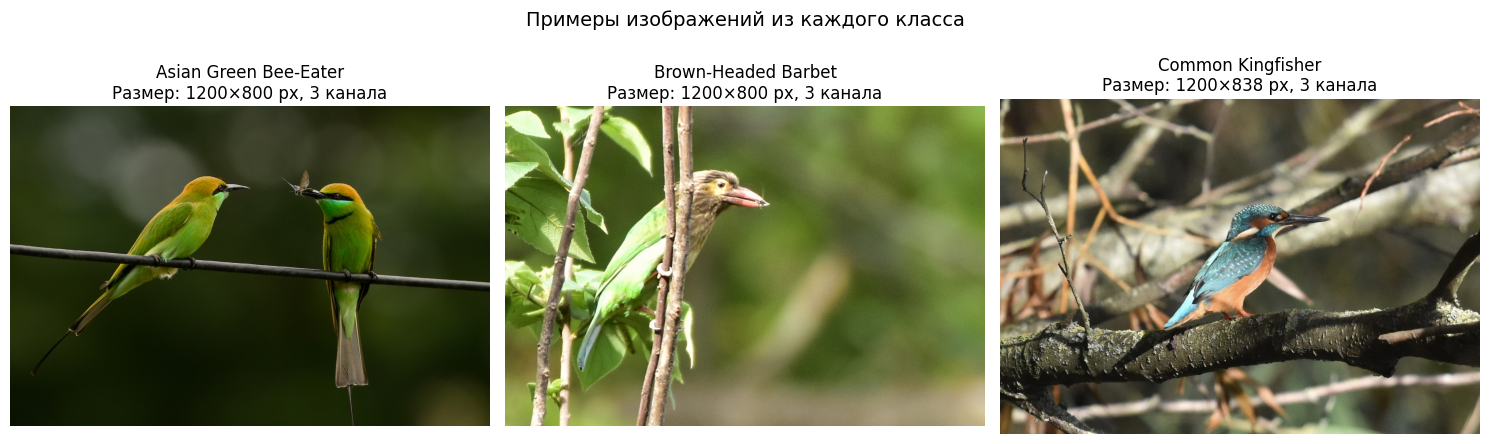

In [ ]:
import cv2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))

for i, cls in enumerate(classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    img_name = os.listdir(cls_path)[0]  # Берём первое изображение
    img = cv2.imread(os.path.join(cls_path, img_name))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV читает в BGR, matplotlib ожидает RGB

    axes[i].imshow(img_rgb)
    axes[i].set_title(f'{cls}\nРазмер: {img.shape[1]}×{img.shape[0]} px, {img.shape[2]} канала')
    axes[i].axis('off')

plt.suptitle('Примеры изображений из каждого класса', fontsize=14)
plt.tight_layout()
plt.show()

### 3. Указываем путь к набору данных:

In [ ]:
DATASET_PATH = '/content/dataset/training_set'

### 4. Загружаем набор данных и формируем общую выборку:

In [ ]:
# Ваш код
IMG_SIZE = 128          # Ширина и высота изображения в пикселях
INPUT_DIM = IMG_SIZE * IMG_SIZE * 3  # Общее число значений: ширина × высота × 3 канала (RGB)

print(f"Целевой размер изображения: {IMG_SIZE}×{IMG_SIZE} пикселей")
print(f"Количество каналов: 3 (цветное изображение)")
print(f"Размерность входного вектора: {IMG_SIZE} × {IMG_SIZE} × 3 = {INPUT_DIM}")

Целевой размер изображения: 128×128 пикселей
Количество каналов: 3 (цветное изображение)
Размерность входного вектора: 128 × 128 × 3 = 49152


In [ ]:
# Разворачиваем изображение в одномерный вектор
sample_cls = classes[0]
sample_dir = os.path.join(DATASET_PATH, sample_cls)
sample_path = os.path.join(sample_dir, os.listdir(sample_dir)[0])
sample_img = cv2.imread(sample_path)
sample_resized = cv2.resize(sample_img, (IMG_SIZE, IMG_SIZE))
sample_flat = sample_resized.flatten()

print(f"Форма изображения:       {sample_resized.shape}  →  (высота, ширина, каналы)")
print(f"Форма вектора:           {sample_flat.shape}  →  одномерный вектор")
print(f"Количество элементов:    {len(sample_flat)}")
print(f"Первые 12 значений:     {sample_flat[:12]}")
print(f"Диапазон значений:      от {sample_flat.min()} до {sample_flat.max()}")

Форма изображения:       (128, 128, 3)  →  (высота, ширина, каналы)
Форма вектора:           (49152,)  →  одномерный вектор
Количество элементов:    49152
Первые 12 значений:     [18 45 36 19 45 39 19 47 34 21 48 37]
Диапазон значений:      от 0 до 248


#### 4.1. Нормализуем данные:

Масштабируем интенсивности пикселей в диапазон [0, 1], а также преобразуем данные в массивы NumPy для повышения производительности


In [ ]:
# Ваш код
import numpy as np
import random
from imutils import paths
from tqdm import tqdm

# Получаем список всех путей к изображениям
imagePaths = sorted(list(paths.list_images(DATASET_PATH)))
random.seed(42)
random.shuffle(imagePaths)  # Перемешиваем для случайного порядка

data = []
labels_str = []

for imagePath in tqdm(imagePaths, desc="Загрузка изображений", unit="img", colour="green"):
    try:
        image = cv2.imread(imagePath)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE)).flatten()
        data.append(image)
        # Метка класса — это имя родительской папки
        label = imagePath.split(os.path.sep)[-2]
        labels_str.append(label)
    except:
        continue  # Пропускаем битые файлы

# Преобразуем в numpy-массивы и нормализуем пиксели
data = np.array(data, dtype="float") / 255.0
labels_str = np.array(labels_str)

Загрузка изображений: 100%|██████████| 2772/2772 [00:49<00:00, 55.74img/s]


In [ ]:
# Проверяем, что данные загружены успешно

print(f"   Массив изображений:  {data.shape}  →  ({data.shape[0]} изображений × {data.shape[1]} признаков)")
print(f"   Массив меток:        {labels_str.shape}")
print(f"   Уникальные классы:   {np.unique(labels_str)}")
print(f"   Диапазон значений:   [{data.min():.1f}, {data.max():.1f}]  (после нормализации)")

   Массив изображений:  (2772, 49152)  →  (2772 изображений × 49152 признаков)
   Массив меток:        (2772,)
   Уникальные классы:   ['Asian Green Bee-Eater' 'Brown-Headed Barbet' 'Common Kingfisher']
   Диапазон значений:   [0.0, 1.0]  (после нормализации)


In [ ]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
labels = lb.fit_transform(labels_str)

print(f"Классы (в алфавитном порядке): {lb.classes_}")
print(f"Форма массива меток: {labels.shape}  →  ({labels.shape[0]} меток × {labels.shape[1]} класса)")
print()
print("Примеры кодирования:")
for cls in lb.classes_:
    idx = np.where(labels_str == cls)[0][0]
    print(f"  '{cls}'  →  {labels[idx]}")

Классы (в алфавитном порядке): ['Asian Green Bee-Eater' 'Brown-Headed Barbet' 'Common Kingfisher']
Форма массива меток: (2772, 3)  →  (2772 меток × 3 класса)

Примеры кодирования:
  'Asian Green Bee-Eater'  →  [1 0 0]
  'Brown-Headed Barbet'  →  [0 1 0]
  'Common Kingfisher'  →  [0 0 1]


#### 4.2. Формируем обучающую и валидационную выборки:

Разделяем данные на обучающую и валидационную выборки, используя 75% данных для обучения и оставшиеся 25% для валидации

In [ ]:
# Ваш код
from sklearn.model_selection import train_test_split

trainX, testX, trainY, testY = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

print(f"Обучающая выборка:  {trainX.shape[0]} изображений,  матрица: {trainX.shape}")
print(f"Тестовая выборка:   {testX.shape[0]} изображений,  матрица: {testX.shape}")
print(f"Метки обучающие:    {trainY.shape}")
print(f"Метки тестовые:     {testY.shape}")

Обучающая выборка:  2217 изображений,  матрица: (2217, 49152)
Тестовая выборка:   555 изображений,  матрица: (555, 49152)
Метки обучающие:    (2217, 3)
Метки тестовые:     (555, 3)


### 5. Создание модели:

#### 5.1. Определим архитектуру модели с помощью Keras:

In [ ]:
# Ваш код
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

num_classes = len(lb.classes_)

model = Sequential()
model.add(Dense(1024, input_shape=(INPUT_DIM,), activation="relu"))
model.add(Dense(512, activation="relu"))
model.add(Dense(256, activation="relu"))
model.add(Dense(num_classes, activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │    50,332,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,989,571 (194.51 MB)

 Trainable params: 50,989,571 (194.51 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2. Установим значение параметров скорости обучения и общего числа эпох


In [ ]:
# Ваш код
from tensorflow.keras.optimizers import SGD

INIT_LR = 0.0001       # Скорость обучения
EPOCHS = 100           # Количество эпох
BATCH_SIZE = 128      # Размер батча

opt = SGD(learning_rate=INIT_LR)

#### 5.3. Компилируем модель:

In [ ]:
# Ваш код
model.compile(
    loss="categorical_crossentropy",
    optimizer=opt,
    metrics=["accuracy"]
)

### 6. Обучение модели искусственной нейронной сети:

#### 6.1. Добавим колбэки для сохранения лучшей модели по валидационной точности и остановки обучения, в случае, если модель перестала обучаться:

In [ ]:
# Ваш код
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

callbacks = [checkpoint,early_stop]

#### 6.2. Запустим процесс обучения модели:

In [ ]:
# Ваш код
H = model.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 856ms/step - accuracy: 0.3374 - loss: 1.1546 - val_accuracy: 0.3784 - val_loss: 1.0973
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 826ms/step - accuracy: 0.3703 - loss: 1.0942 - val_accuracy: 0.4072 - val_loss: 1.0875
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 845ms/step - accuracy: 0.3918 - loss: 1.0845 - val_accuracy: 0.4288 - val_loss: 1.0783
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 845ms/step - accuracy: 0.4187 - loss: 1.0731 - val_accuracy: 0.4595 - val_loss: 1.0698
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 871ms/step - accuracy: 0.4559 - loss: 1.0600 - val_accuracy: 0.4432 - val_loss: 1.0651
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 825ms/step - accuracy: 0.4452 - loss: 1.0548 - val_accuracy: 0.4432 - val_loss: 1.0587
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 840ms/step - accuracy: 0.4656 - loss: 1.0459 - val_accuracy: 0.4847 - val_loss: 1.0497
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 930ms/step - accuracy: 0.4671 - loss: 1.0460 - 

#### 6.3. Загружаем лучшую модель:

In [ ]:
# Ваш код
from tensorflow.keras.models import load_model

best_model = load_model("best_model.keras")

### 7. Оценка точности:

#### 7.1. Выведем отчет классификации

In [ ]:
# Ваш код
from sklearn.metrics import classification_report

preds = best_model.predict(testX, batch_size=32)

print(classification_report(
    testY.argmax(axis=1),
    preds.argmax(axis=1),
    target_names=lb.classes_
))

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step
                       precision    recall  f1-score   support

Asian Green Bee-Eater       0.57      0.67      0.62       168
  Brown-Headed Barbet       0.63      0.62      0.62       194
    Common Kingfisher       0.59      0.52      0.55       193

             accuracy                           0.60       555
            macro avg       0.60      0.60      0.60       555
         weighted avg       0.60      0.60      0.60       555



#### 7.2. Выведем матрицу ошибок

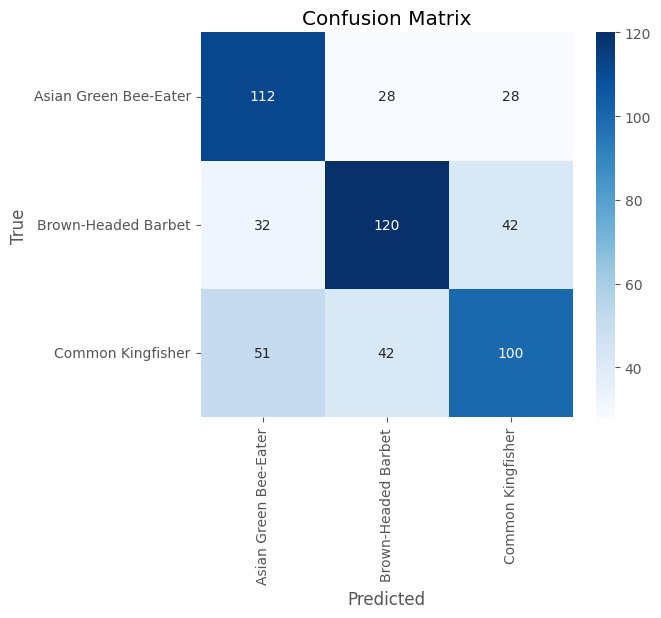

In [ ]:
# Ваш код
import seaborn as sns
from sklearn.metrics import confusion_matrix
y_true = testY.argmax(axis=1)      # реальные классы
y_pred = preds.argmax(axis=1)      # предсказанные классы

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=lb.classes_,
            yticklabels=lb.classes_,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

#### 7.3. Отобразим график обучения

In [ ]:
H.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

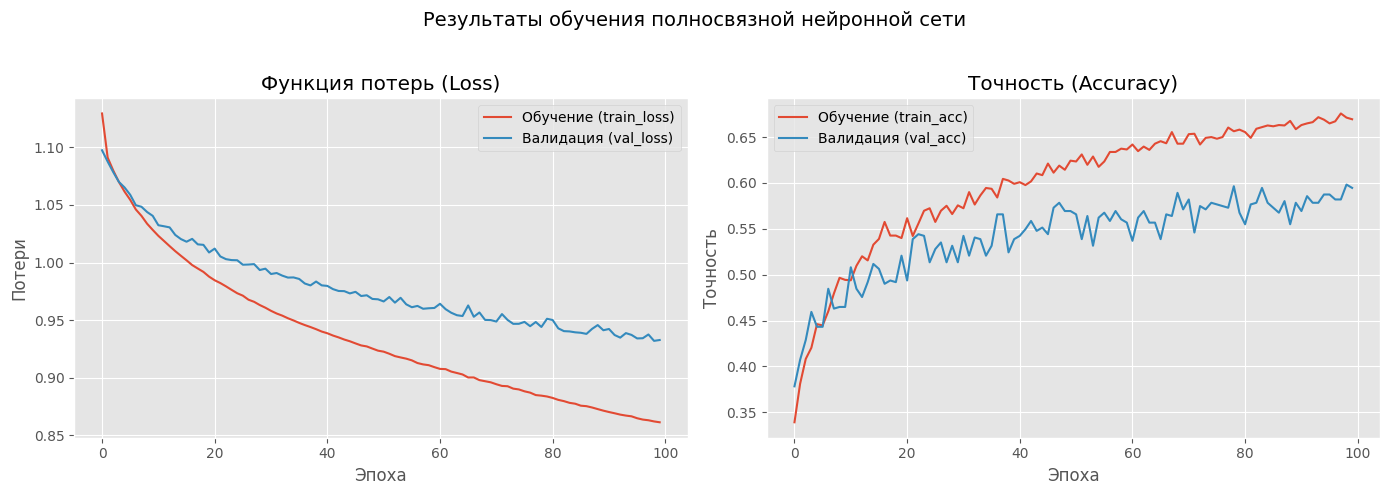

In [ ]:
epochs_range = np.arange(len(H.history["loss"]))
plt.style.use("ggplot")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Потери
ax1.plot(epochs_range, H.history["loss"], label="Обучение (train_loss)")
ax1.plot(epochs_range, H.history["val_loss"], label="Валидация (val_loss)")
ax1.set_title("Функция потерь (Loss)")
ax1.set_xlabel("Эпоха")
ax1.set_ylabel("Потери")
ax1.legend()

# Точность
ax2.plot(epochs_range, H.history["accuracy"], label="Обучение (train_acc)")
ax2.plot(epochs_range, H.history["val_accuracy"], label="Валидация (val_acc)")
ax2.set_title("Точность (Accuracy)")
ax2.set_xlabel("Эпоха")
ax2.set_ylabel("Точность")
ax2.legend()

plt.suptitle("Результаты обучения полносвязной нейронной сети", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 8. Сохранение модели и меток классов:

In [ ]:
# Ваш код
model.save("/content/dataset/birds.h5", save_format="h5")
np.save("/content/dataset/classes.npy", lb.classes_)

print("✅ Модель сохранена:  birds.h5")
print("✅ Классы сохранены:  classes.npy")

✅ Модель сохранена:  birds.h5
✅ Классы сохранены:  classes.npy


### 9. Проверка обученной модели пользовательскими данными:

#### 9.1. Импортируем необходимые библиотеки

In [ ]:
# Ваш код
from google.colab import files
from google.colab.patches import cv2_imshow
from tensorflow.keras.models import load_model

#### 9.2. Реализуем функцию для предобработки входных данных в той же последовательности, что и при формировании обучающей выборки:

In [ ]:
def upload_image():
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    image = cv2.imread(filename)
    return filename, image
def preprocess_image(image, img_size):
    image_resized = cv2.resize(image, (img_size, img_size))
    image_flat = image_resized.flatten().astype("float32") / 255.0
    image_processed = image_flat.reshape((1, -1))
    return image_processed

#### 9.3. Определим функцию для осуществления прогноза по загруженной модели:

In [ ]:
def load_trained_model(model_path, classes_path):
    model = load_model(model_path, compile=False)
    class_names = np.load(classes_path, allow_pickle=True)
    return model, class_names
def make_prediction(model, image_processed):
    preds = model.predict(image_processed)
    idx = preds.argmax(axis=1)[0]
    confidence = preds[0][idx] * 100
    return preds, idx, confidence

### 10. Визуализируем интерфейс и произведем классификацию:

Saving Brown_headed_Barbet_I2_IMG_8449.jpg to Brown_headed_Barbet_I2_IMG_8449 (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


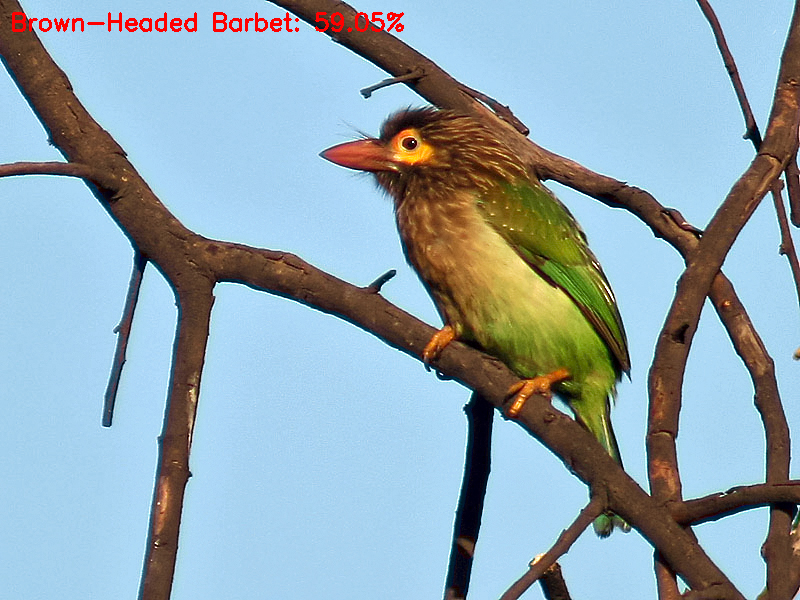


✅ Итог: Brown-Headed Barbet (59.05%)

📊 Вероятности по классам:
   Asian Green Bee-Eater:  17.72%  █████
     Brown-Headed Barbet:  59.05%  █████████████████
       Common Kingfisher:  23.23%  ██████


In [ ]:
def show_result(image, class_names, idx, confidence):
    output = image.copy()
    label = str(class_names[idx])
    text = f"{label}: {confidence:.2f}%"

    cv2.putText(output, text, (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                (0, 0, 255), 2)

    cv2_imshow(output)
    return label
def print_probabilities(class_names, preds, bar_scale=30):
    print("\n📊 Вероятности по классам:")
    for cls, prob in zip(class_names, preds[0]):
        bar = "█" * int(prob * bar_scale)
        print(f"{str(cls):>24s}: {prob*100:6.2f}%  {bar}")

MODEL_PATH = "/content/dataset/birds.h5"
CLASSES_PATH = "/content/dataset/classes.npy"


filename, image = upload_image()
image_processed = preprocess_image(image, IMG_SIZE)
model, class_names = load_trained_model(MODEL_PATH, CLASSES_PATH)

preds, idx, confidence = make_prediction(model, image_processed)

label = show_result(image, class_names, idx, confidence)
print(f"\n✅ Итог: {label} ({confidence:.2f}%)")
print_probabilities(class_names, preds)